<a href="https://colab.research.google.com/github/GUC-DM/w25-mini-project-3-valerie-antonioust02-hassan-ahmedt02/blob/main/Clustering_Mini_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Clustering - Mini-Project 3

***Edit this cell with your name(s), tutorial number and ID(s)***

---

Name:Hassan Eltayeb

ID:58-16514

Tutorial:2

---

Name:Valerie Antonious

ID:59-30018

Tutorial:2

---


## Dataset Description

The dataset file contains almost ~3000 different music genres aggregated from more than 160.000 songs collected from Spotify Web API.

Primary:

- genre (Music genre)

Numerical:

- acousticness (Ranges from 0 to 1)
- danceability (Ranges from 0 to 1)
- energy (Ranges from 0 to 1)
- duration_ms (Integer typically ranging from 200k to 300k)
- instrumentalness (Ranges from 0 to 1)
- valence (Ranges from 0 to 1)
- popularity (Ranges from 0 to 100)
- tempo (Float typically ranging from 50 to 150)
- liveness (Ranges from 0 to 1)
- loudness (Float typically ranging from -60 to 0 in decibels (dB))
- speechiness (Ranges from 0 to 1)


Categorical:

- key (All keys on octave encoded as values ranging from 0 to 11, starting on C as 0, C# as 1 and so on…)


**Recommended Reading for Data Understanding**: Spotify's documentation of audio features: https://developer.spotify.com/documentation/web-api/reference/tracks/get-audio-features/

**Acknowledgment**: This dataset was created and published by Yamaç Eren Ay on Kaggle.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
plt.style.use('fivethirtyeight')
sns.set_style('whitegrid')

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/GUC-DM/W2025/refs/heads/main/data/music_genres.csv')
df.head()

,genres,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,key
0,21st century classical,0.979333,0.162883,1.602977e+05,0.071317,0.606834,0.361600,-31.514333,0.040567,75.336500,0.103783,27.833333,6
1,432hz,0.494780,0.299333,1.048887e+06,0.450678,0.477762,0.131000,-16.854000,0.076817,120.285667,0.221750,52.500000,5
2,8-bit,0.762000,0.712000,1.151770e+05,0.818000,0.876000,0.126000,-9.180000,0.047000,133.444000,0.975000,48.000000,7
3,a cappella,0.676557,0.538961,1.906285e+05,0.316434,0.003003,0.172254,-12.479387,0.082851,112.110362,0.448249,45.820071,7
4,abstract,0.459210,0.516167,3.431965e+05,0.442417,0.849667,0.118067,-15.472083,0.046517,127.885750,0.307325,43.500000,1


Data inspection

In [3]:
# DATA INSPECTION

# 1. Display the first 5 rows of the dataset
#    This helps us verify the dataset loaded correctly and shows the structure of the data.
df.head()


,genres,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,key
0,21st century classical,0.979333,0.162883,1.602977e+05,0.071317,0.606834,0.361600,-31.514333,0.040567,75.336500,0.103783,27.833333,6
1,432hz,0.494780,0.299333,1.048887e+06,0.450678,0.477762,0.131000,-16.854000,0.076817,120.285667,0.221750,52.500000,5
2,8-bit,0.762000,0.712000,1.151770e+05,0.818000,0.876000,0.126000,-9.180000,0.047000,133.444000,0.975000,48.000000,7
3,a cappella,0.676557,0.538961,1.906285e+05,0.316434,0.003003,0.172254,-12.479387,0.082851,112.110362,0.448249,45.820071,7
4,abstract,0.459210,0.516167,3.431965e+05,0.442417,0.849667,0.118067,-15.472083,0.046517,127.885750,0.307325,43.500000,1


This shows the first few rows so we can confirm the dataset loaded correctly. Most columns look clean and already numeric, duration_ms might need converting to seconds to make it easier to work with. Each row represents a music genre, while the columns describe averaged audio features such as acousticness, danceability, energy, tempo, and popularity.

In [4]:
# Inspect dataset information
#    info() shows data types, non-null counts, and memory usage.
#    This helps detect missing values and incorrect data types early.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2972 entries, 0 to 2971
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   genres            2972 non-null   object 
 1   acousticness      2972 non-null   float64
 2   danceability      2972 non-null   float64
 3   duration_ms       2972 non-null   float64
 4   energy            2972 non-null   float64
 5   instrumentalness  2972 non-null   float64
 6   liveness          2972 non-null   float64
 7   loudness          2972 non-null   float64
 8   speechiness       2972 non-null   float64
 9   tempo             2972 non-null   float64
 10  valence           2972 non-null   float64
 11  popularity        2972 non-null   float64
 12  key               2972 non-null   int64  
dtypes: float64(11), int64(1), object(1)
memory usage: 302.0+ KB


This displays each column’s data type and missing values. All columns have 0 missing entries, and most features are already numeric. Only the genres column is an object type.

In [5]:
# List the unique values of categorical columns
#    This is useful for detecting typos, inconsistent categories, or unexpected values.
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    print(f"\nColumn: {col}")
    print(df[col].unique())



Column: genres
['21st century classical' '432hz' '8-bit' ... 'zouk' 'zurich indie'
 'zydeco']


This lists the unique values in the categorical column. The genres column contains many different genre labels, and they all appear to be valid music categories with no obvious typos or strange formatting. Everything looks consistent

In [6]:
# Statistical summary for ALL columns (numeric + categorical)
# include='all' makes describe() include object/categorical columns
df.describe(include='all')

,genres,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,key
count,2972,2972.000000,2972.000000,2.972000e+03,2972.000000,2972.000000,2972.000000,2972.000000,2972.000000,2972.000000,2972.000000,2972.000000,2972.000000
unique,2972,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,zydeco,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,0.401157,0.537190,2.517272e+05,0.561190,0.211368,0.192791,-10.509249,0.083580,119.020796,0.492741,39.925598,5.938425
std,NaN,0.319781,0.150693,9.467215e+04,0.234511,0.267374,0.092370,5.370006,0.080495,17.471762,0.201853,16.747890,3.368621
min,NaN,0.000003,0.056900,3.094600e+04,0.001002,0.000000,0.022200,-41.825000,0.023800,47.135722,0.003353,0.000000,0.000000
25%,NaN,0.119036,0.441169,2.063674e+05,0.395030,0.004829,0.137682,-12.428814,0.044900,109.191107,0.348558,32.531911,3.000000
50%,NaN,0.321706,0.546511,2.375479e+05,0.601264,0.080663,0.178752,-9.219409,0.059432,119.199333,0.499936,43.059365,7.000000
75%,NaN,0.674088,0.647536,2.773008e+05,0.730202,0.343333,0.220858,-6.919969,0.091000,127.510813,0.640380,51.139881,9.000000


This summary shows the distribution of each column. The genres column has 2972 unique values, which makes sense because each track has its own genre label. The dataset contains 2,972 unique music genres with several numerical audio features. Most features are scaled between 0 and 1, making them suitable for analysis and clustering. Popularity varies widely across genres, showing clear differences in listener interest.

In [7]:
# Check how many missing values each column has
df.isnull().sum()

,0
genres,0
acousticness,0
danceability,0
duration_ms,0
energy,0
instrumentalness,0
liveness,0
loudness,0
speechiness,0
tempo,0


This shows that their are no missing values withen the data

Data cleaning

In [8]:
# Convert song duration from milliseconds to seconds
df['duration_sec'] = df['duration_ms'] / 1000

The duration_ms values are very large, making them hard to interpret. Converting to seconds creates a new column duration_sec that is easier to analyze and compare.

In [9]:
from sklearn.preprocessing import MinMaxScaler

# Select numeric columns to normalize
numeric_cols = ['acousticness', 'danceability', 'duration_sec', 'energy',
                'instrumentalness', 'liveness', 'loudness', 'speechiness',
                'tempo', 'valence', 'popularity', 'key']

# Initialize MinMaxScaler
scaler = MinMaxScaler()

# Fit and transform numeric columns
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

# Check result
df[numeric_cols].head()


,acousticness,danceability,duration_sec,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,key
0,0.983266,0.121527,0.055005,0.070763,0.611727,0.361911,0.246166,0.018177,0.179536,0.102832,0.345041,0.545455
1,0.496766,0.277988,0.432864,0.452544,0.481615,0.116016,0.596180,0.057476,0.465697,0.223620,0.650826,0.454545
2,0.765060,0.751175,0.035818,0.822207,0.883065,0.110685,0.779396,0.025151,0.549467,0.994880,0.595041,0.636364
3,0.679274,0.552759,0.067903,0.317443,0.003028,0.160007,0.700623,0.064018,0.413650,0.455534,0.568017,0.636364
4,0.461053,0.526622,0.132780,0.444229,0.856519,0.102225,0.629173,0.024627,0.514082,0.311241,0.539256,0.090909


All numeric features have been scaled to a 0–1 range. This makes features like duration_sec, tempo, and loudness comparable to features that were already between 0 and 1, ensuring no single feature controls the clustering process so We did normalization so that all numbers are on the same scale. This way, big numbers like duration_sec or tempo don’t take over the clustering, and every feature has a fair impact.


In [10]:
# Select ONLY musical numeric features for clustering
X = df[[
    'danceability', 'energy', 'loudness', 'speechiness', 'acousticness',
    'instrumentalness', 'liveness', 'valence', 'tempo'
]].copy()
#dropping genere because we cluster based in new generes and dropping ket because its numerical
X.head()


,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
0,0.121527,0.070763,0.246166,0.018177,0.983266,0.611727,0.361911,0.102832,0.179536
1,0.277988,0.452544,0.596180,0.057476,0.496766,0.481615,0.116016,0.223620,0.465697
2,0.751175,0.822207,0.779396,0.025151,0.765060,0.883065,0.110685,0.994880,0.549467
3,0.552759,0.317443,0.700623,0.064018,0.679274,0.003028,0.160007,0.455534,0.413650
4,0.526622,0.444229,0.629173,0.024627,0.461053,0.856519,0.102225,0.311241,0.514082


We chose only the numeric music features because these values describe how each song actually sounds. K-Means needs numbers to compare songs, so using these features helps the algorithm group songs based on real musical similarities. This step makes sure the clustering is based on sound characteristics and not on text labels like genre names. The key feature is also excluded because it represents musical categories encoded as numbers, and the numerical distance between keys does not reflect real musical similarity. Selecting only relevant sound-related features ensures that the clustering is based on meaningful musical patterns.

Exploratory Data Analysis

Q1:What factors affect the Popularity of the song? (Mention the two biggest factors, with interpretation)

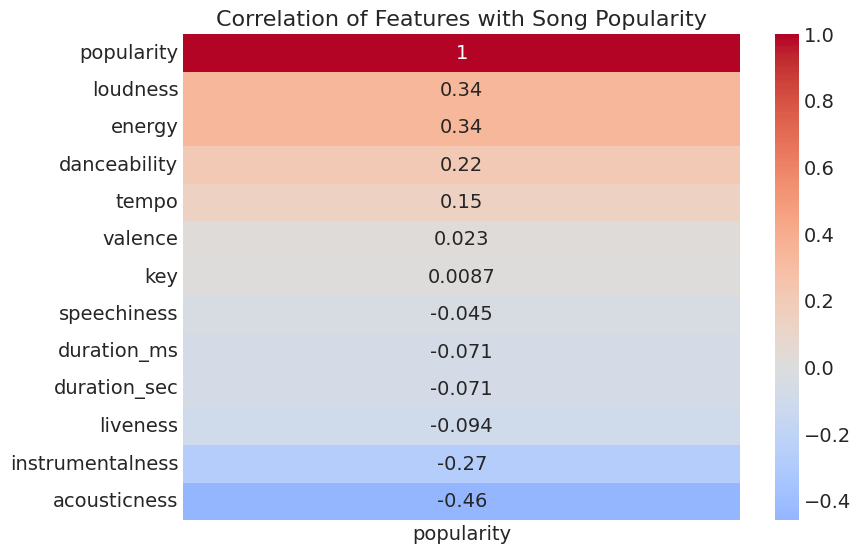

In [11]:
# Compute correlations with popularity
pop_corr = df.corr(numeric_only=True)[['popularity']].sort_values(by='popularity', ascending=False)

# Visualize correlations as a heatmap
plt.figure(figsize=(8,6))
sns.heatmap(pop_corr, annot=True, cmap='coolwarm', center=0, cbar=True)
plt.title('Correlation of Features with Song Popularity', fontsize=16)
plt.show()


A heatmap is used because it clearly shows the strength and direction of relationships between many numerical features at once. It uses colors to quickly highlight strong positive and negative correlations, making patterns easy to spot. In this analysis, the heatmap reveals key relationships such as the strong positive link between energy and loudness and the strong negative link between acousticness and energy, helping us understand how musical features interact.

The correlation of each feature with popularity shows which factors are most associated with a song’s popularity.
Positive correlations:
Loudness (0.34): Both loudness and energy show the strongest positive correlations with popularity. This indicates that louder and more energetic songs tend to be more popular. Such songs are often more engaging, upbeat, and suitable for mainstream listening, playlists, and social settings.
Energy (0.34): Songs with higher energy levels are generally more popular.
Danceability (0.22): More danceable songs slightly tend to be more popular.
Negative correlations:
Acousticness (-0.46): This is the strongest relationship with popularity and it is negative. This means that songs that are more acoustic (for example, calm, unplugged, or classical-style music) tend to be less popular. In contrast, songs that are less acoustic and more produced or electronic usually attract more listeners.
Instrumentalness (-0.27): Songs with more instrumental content tend to be less popular.
Interpretation:
Popularity appears to be driven mostly by acousticness (negatively) and loudness (positively), meaning loud, energetic songs that are less acoustic tend to attract more listeners.

Q2:Which genre is the most popular and which is the least?

/tmp/ipython-input-1866465784.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10.values, y=top_10.index, palette='viridis')


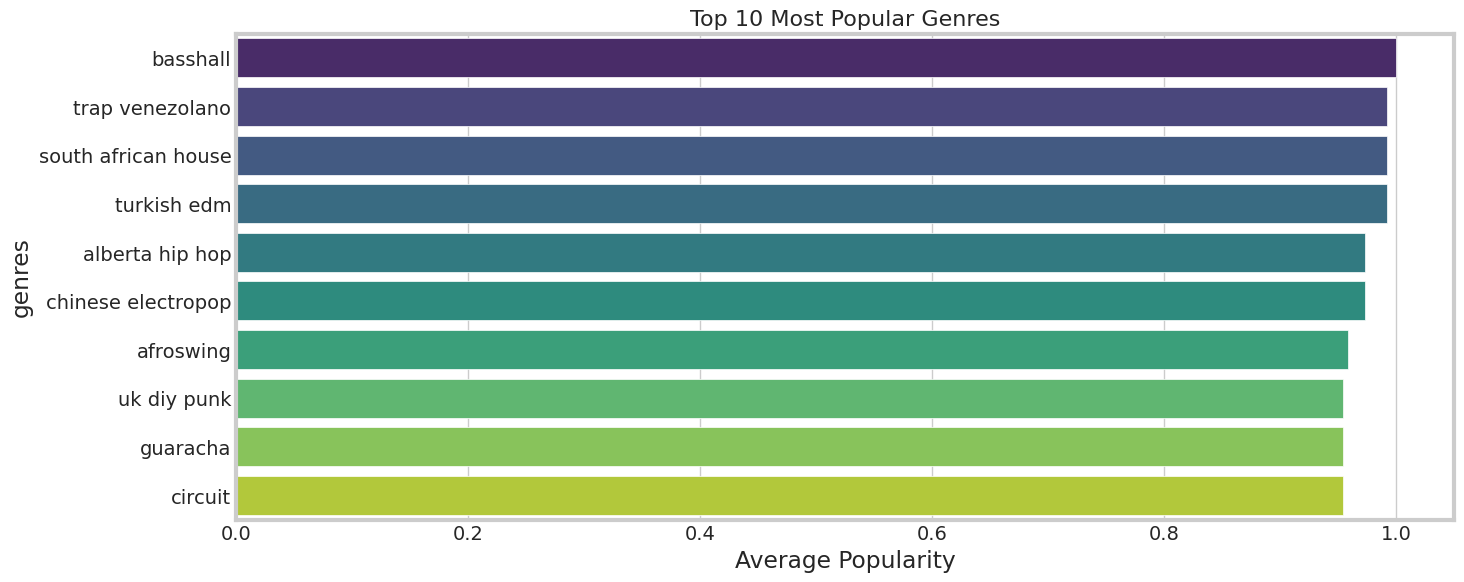

/tmp/ipython-input-1866465784.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=bottom_10.values, y=bottom_10.index , palette='magma')


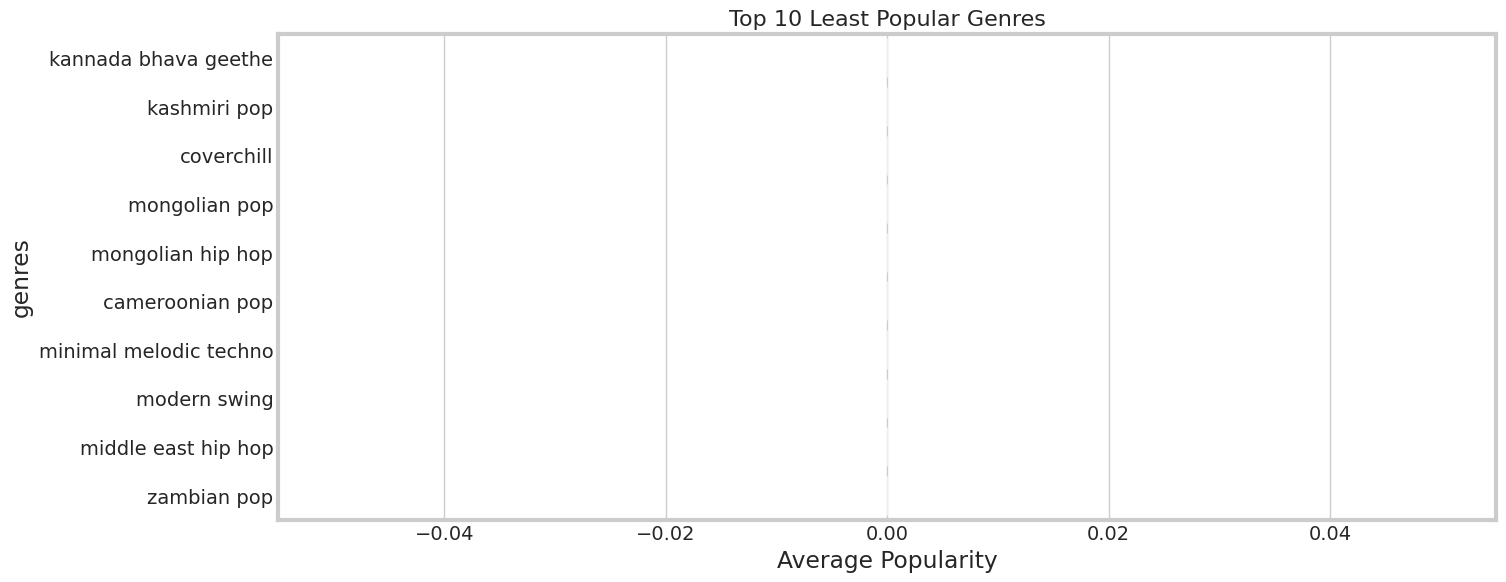

/tmp/ipython-input-1866465784.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=bottom_10_non_zero.values, y=bottom_10_non_zero.index, palette='magma')


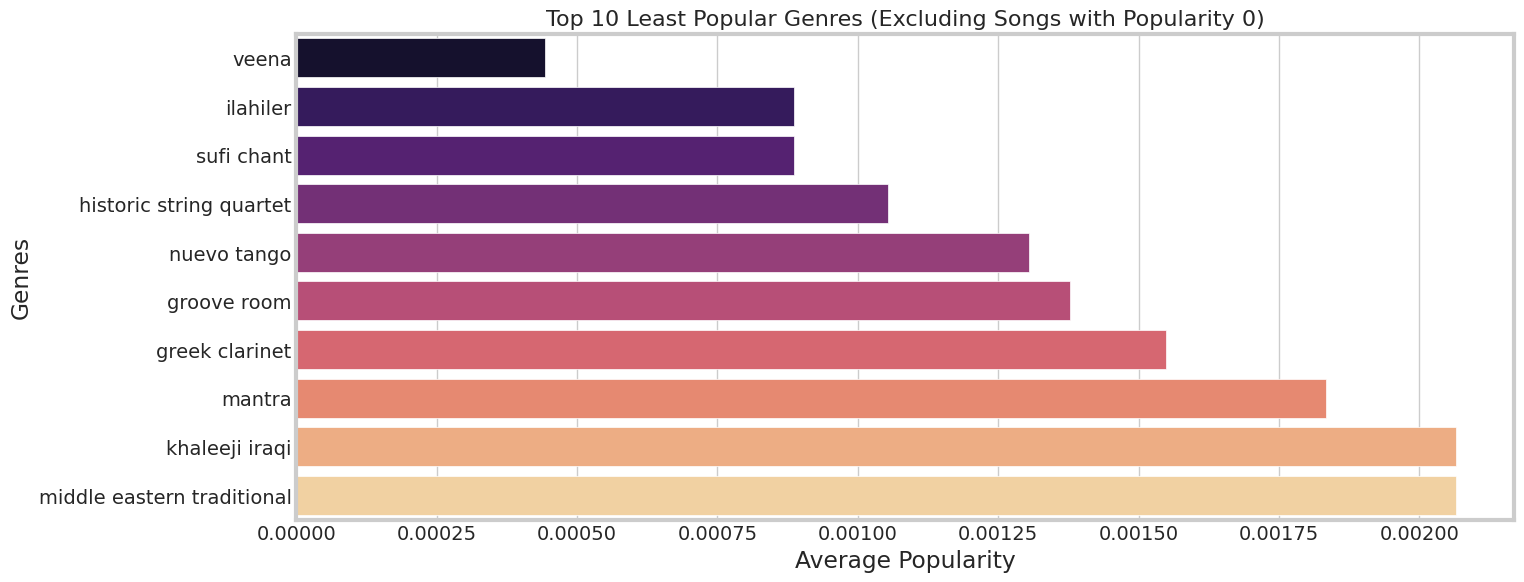

In [12]:
# Group by genre and compute mean popularity
genre_popularity = df.groupby('genres')['popularity'].mean().sort_values(ascending=False)

# Select top 10 and bottom 10 genres
top_10 = genre_popularity.head(10)
bottom_10 = genre_popularity.tail(10)

# Visualization
plt.figure(figsize=(14,6))
sns.barplot(x=top_10.values, y=top_10.index, palette='viridis')
plt.title('Top 10 Most Popular Genres', fontsize=16)
plt.xlabel('Average Popularity')
plt.show()

plt.figure(figsize=(14,6))
sns.barplot(x=bottom_10.values, y=bottom_10.index , palette='magma')
plt.title('Top 10 Least Popular Genres', fontsize=16)
plt.xlabel('Average Popularity')
plt.show()

# Filter out songs with popularity == 0
df_non_zero = df[df['popularity'] != 0]

# Group by genre and compute mean popularity
genre_popularity_non_zero = df_non_zero.groupby('genres')['popularity'].mean()

# Select the 10 least popular genres
bottom_10_non_zero = genre_popularity_non_zero.nsmallest(10)

# Visualization
plt.figure(figsize=(14,6))
sns.barplot(x=bottom_10_non_zero.values, y=bottom_10_non_zero.index, palette='magma')
plt.title('Top 10 Least Popular Genres (Excluding Songs with Popularity 0)', fontsize=16)
plt.xlabel('Average Popularity')
plt.ylabel('Genres')
plt.show()


We calculated the average popularity for each genre to determine which music genres are the most and least popular. The bar plots allow us to visualize these differences easily. Based on our analysis: the most popular genres are Basshall, Trap Venezolano, South African House, Turkish EDM, Alberta Hip Hop, Chinese Electropop, Afroswing, UK Div Punk, Quaracha, and Circuit, while the least popular genres are Kannada Bhava Geethe, Kashmiri Pop, Coverchill, Mongolian Pop, Mongolian Hip Hop, Cameroonian Pop, Minimal Melodic Techno, Modern Swing, Middle East Hip Hop, and Zambian Pop.

Most popular genre: Basshall
Basshall has the highest average popularity among all genres in the dataset. This indicates that it attracts a large number of listeners and has strong mainstream appeal compared to other genres.

Least popular genre: Kannada Bhava Geethe
When considering all genres, Kannada Bhava Geethe appears as the least popular, with an average popularity close to zero. This suggests that it is a very niche or region-specific genre with limited global listening.

Additional clarification excluding zero-popularity genres:
After excluding genres with popularity equal to zero, Veena becomes the least popular genre. This adjustment helps avoid bias caused by genres that have no recorded popularity at all and gives a clearer view of the least popular genres that still have some listener presence.

Q3:What are the most correlated pairs of attributes? (Mention 2 pairs, with interpretation)

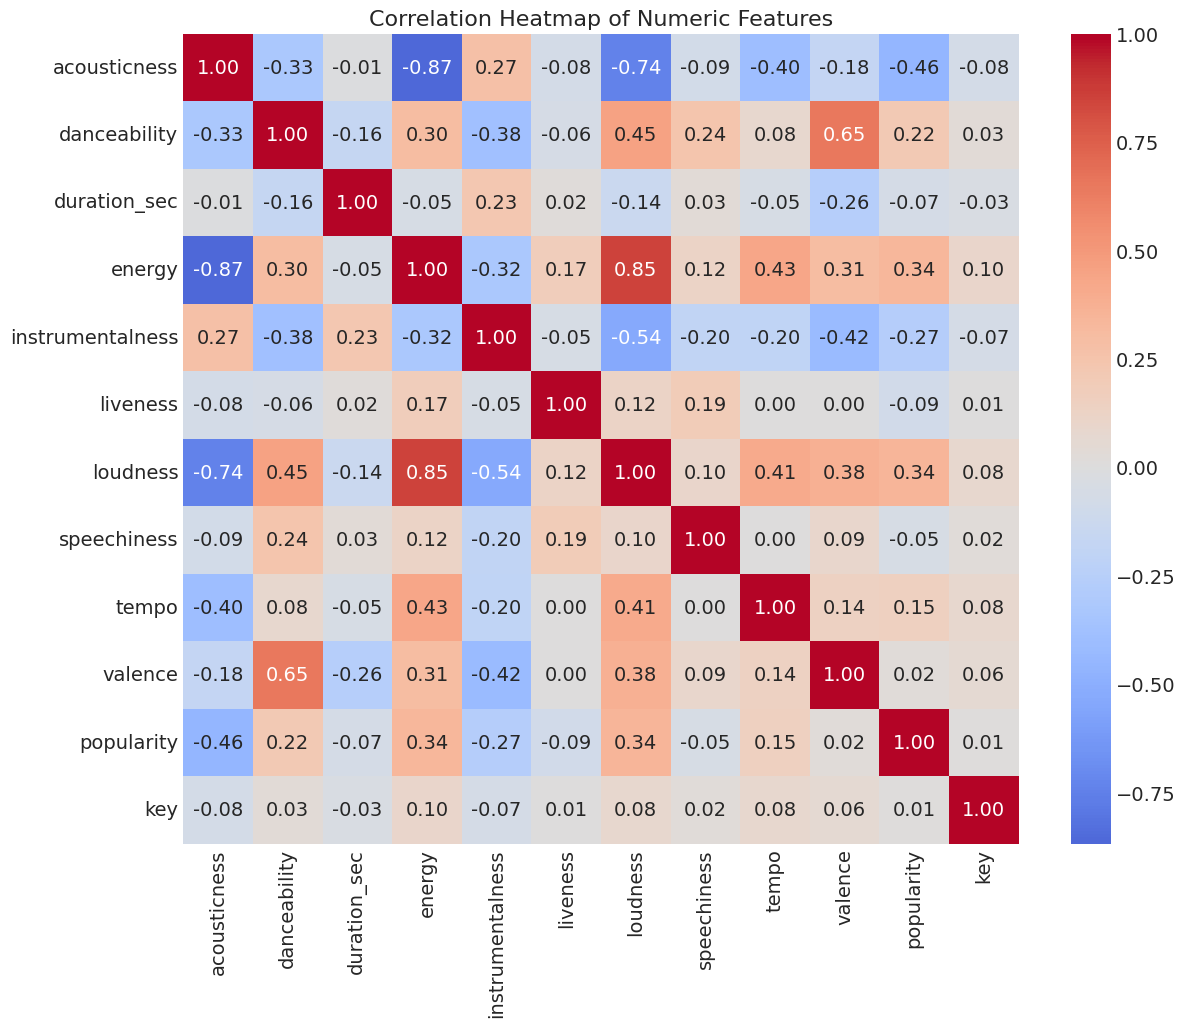

In [13]:
# Calculate the correlation matrix
corr_matrix = df[numeric_cols].corr()

# Visualize correlations using a heatmap
plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title("Correlation Heatmap of Numeric Features", fontsize=16)
plt.show()


A heatmap is used because it clearly shows the strength and direction of relationships between many numerical features at once. It uses colors to quickly highlight strong positive and negative correlations, making patterns easy to spot. In this analysis, the heatmap reveals key relationships such as the strong positive link between energy and loudness and the strong negative link between acousticness and energy, helping us understand how musical features interact.

The heatmap shows how different music features relate to each other. The strongest positive correlation is between energy and loudness (0.85), meaning energetic songs tend to be louder. The strongest negative correlation is between acousticness and energy (-0.87), showing that acoustic songs are usually less energetic. These relationships help explain how musical traits often appear together or oppose each other.

Energy and Loudness (correlation ≈ +0.85)
This is the strongest positive correlation in the dataset. It shows that songs with higher energy levels tend to be louder. This makes sense musically, as energetic songs often have stronger beats, higher intensity, and greater sound levels.

Acousticness and Energy (correlation ≈ −0.87)
This is the strongest negative correlation. It indicates that songs with high acousticness are usually low in energy. In other words, acoustic music is generally calmer and less intense, while high-energy songs tend to rely more on electronic or amplified sounds.

Interpretation:
These correlations reflect real-world music characteristics and confirm that the dataset captures meaningful relationships between audio features. They also help explain why certain musical traits often appear together or oppose each other.

Q4:Plot the frequency of words in genres. Which main genre categories have the most sub-genres? (mention at least 3)

/tmp/ipython-input-3831912719.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(top_words.keys()), y=list(top_words.values()), palette='viridis')


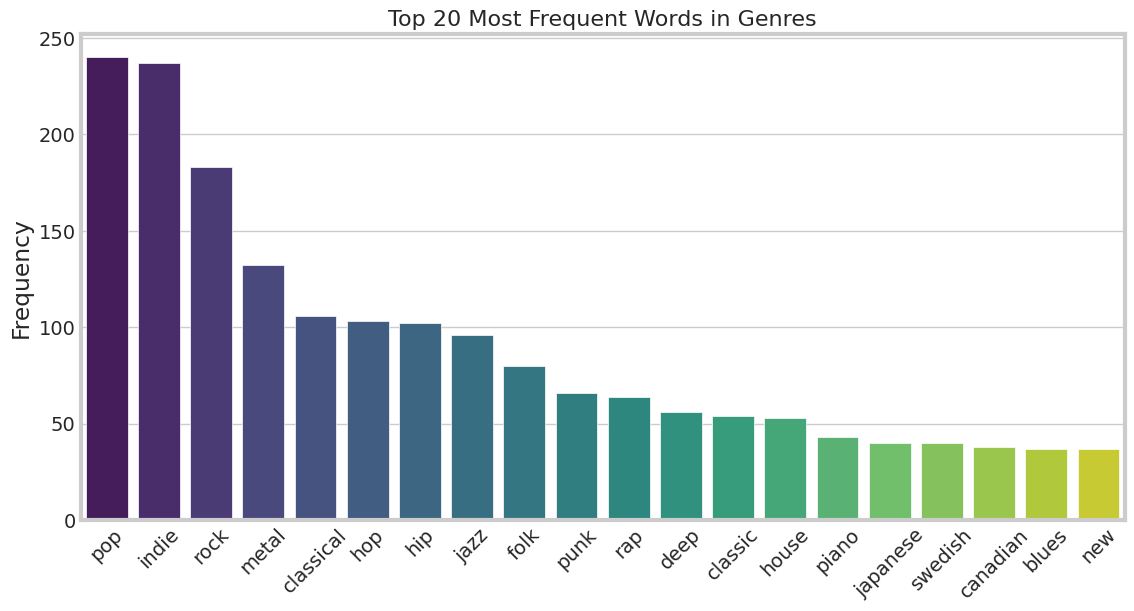

In [14]:
from collections import Counter
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Split all genre names into words and count frequency
genre_words = " ".join(df['genres']).lower().split()
word_freq = Counter(genre_words)

# Select the top 20 most common words for visualization
top_words = dict(word_freq.most_common(20))

# Plot using a bar chart
plt.figure(figsize=(12,6))
sns.barplot(x=list(top_words.keys()), y=list(top_words.values()), palette='viridis')
plt.xticks(rotation=45)
plt.title("Top 20 Most Frequent Words in Genres", fontsize=16)
plt.ylabel("Frequency")
plt.show()

A bar chart was used because it is best for comparing frequencies of categorical data. It clearly shows how often each genre-related word appears and makes it easy to identify the most common ones. The chart reveals that pop, indie, and rock are the most frequent words, meaning they are the main genre categories with the highest number of sub-genres.

From the bar chart showing the frequency of words in genre names, we can see that certain words appear much more often than others. The most frequent words are pop, indie, and rock, indicating that these are the main genre categories with the largest number of sub-genres. Other common categories include metal, classical, and hip hop, which also appear frequently across different genre names.

Interpretation:
The high frequency of these words suggests that pop, indie, and rock are broad genre families that have been extensively subdivided into many styles (such as indie pop, synth-pop, alternative rock, and punk rock). This shows that these genres are highly diverse and widely represented in the dataset.

Q5:Create an additional visualization that differs from earlier ones. Your visualization must highlight a new data relationship or finding. Provide a short explanation of the insight and its relevance.


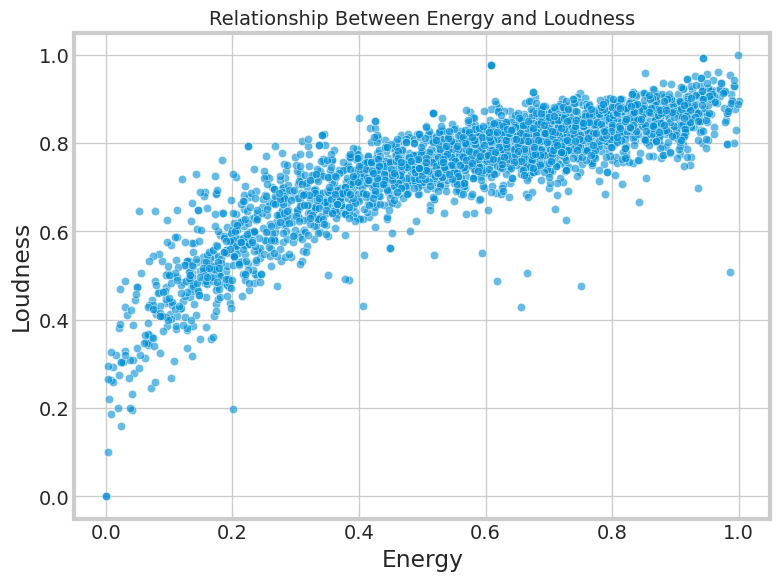

In [15]:
# Create a figure with a specific size for better visibility
plt.figure(figsize=(8, 6))

# Create a scatter plot to show the relationship between energy and loudness
# Each point represents one song in the dataset
sns.scatterplot(
    x='energy',      # Energy values on the x-axis
    y='loudness',    # Loudness values on the y-axis
    data=df,         # Dataset containing the musical features
    alpha=0.6        # Transparency to reduce overlapping points
)

# Add a title to explain what the plot represents
plt.title('Relationship Between Energy and Loudness', fontsize=14)

# Label the x-axis to indicate energy levels
plt.xlabel('Energy')

# Label the y-axis to indicate loudness levels
plt.ylabel('Loudness')

# Display the scatter plot
plt.show()




A scatter plot was used because it is the most suitable visualization for examining the relationship between two continuous numerical variables. Unlike bar charts or boxplots, scatter plots allow us to see patterns, trends, and correlations between variables across all data points, rather than just summary statistics.

In this case, the scatter plot shows the relationship between energy and loudness. Each point represents a genre, and the overall upward trend clearly indicates a strong positive relationship between the two features. As energy increases, loudness also increases. This means that more energetic music tends to be louder, which aligns with real-world music characteristics.

This visualization helps confirm earlier correlation results by visually demonstrating the relationship rather than only relying on numerical values. Therefore, the scatter plot effectively highlights how these two important musical features interact and supports the interpretation used in both exploratory data analysis and clustering.

Data Preparation for Modelling



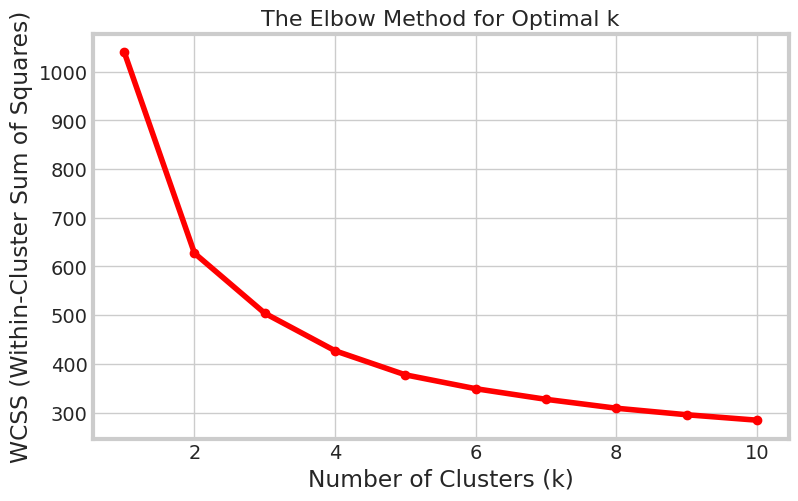

In [16]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# We try out different number of clusters incrementally
# From 1 to 10
wcss = []
for i in range(1, 11):
    km = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=42)
    km.fit(X)  # Use your normalized musical features
    wcss.append(km.inertia_)

# Plot the Elbow graph
plt.figure(figsize=(8,5))
plt.plot(range(1, 11), wcss, marker='o', color='red')
plt.title('The Elbow Method for Optimal k', fontsize=16)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.show()

The elbow method is used to determine the most appropriate number of clusters for K-Means clustering. It works by measuring how the within-cluster sum of squares (WCSS) changes as the number of clusters increases. WCSS represents how closely data points are grouped around their cluster centers, so lower values indicate better clustering.

The plot shows the relationship between the number of clusters (k) and WCSS. At first, increasing k leads to a large reduction in WCSS because the data is being split into more meaningful groups. After a certain point, adding more clusters results in only small improvements. This point, known as the “elbow,” indicates the optimal number of clusters, as it balances clustering quality with model simplicity and helps avoid overfitting.

 This graph helps us choose how many clusters to use. At first, the error drops a lot when we increase the number of clusters, but after a certain point the improvement becomes small. From the graph, the curve starts to flatten around 4 to 5 clusters. This means adding more clusters does not improve the result much. We chose 5 clusters to get slightly more detailed groups while still keeping the model simple.

In [17]:
from sklearn.cluster import KMeans

# Apply K-Means clustering with k = 5
km = KMeans(
    n_clusters=5,
    init='k-means++',
    max_iter=300,
    n_init=10,
    random_state=42
)

km.fit(X)  # X contains the selected musical features

# Get the cluster labels
labels = km.labels_
labels


array([1, 1, 3, ..., 0, 2, 0], dtype=int32)

This step applies the K-Means algorithm using 5 clusters to group the genres based on their musical features. As a result, each genre is assigned to one of five clusters according to how similar it is to others. The output array shows the cluster label for each genre, confirming that the clustering process was successful. These labels will be used next to analyze and interpret the characteristics of each cluster.

In [18]:
# Assign the cluster labels from K-Means to a new column called 'cluster' in your dataframe
df['cluster'] = labels

# Optional: Prevent pandas from truncating output so you can see all columns and rows
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

# Display descriptive statistics for each cluster
df.groupby('cluster').describe()


acousticness                                                    \
               count      mean       std       min       25%       50%   
cluster                                                                  
0              955.0  0.251396  0.139077  0.000215  0.147132  0.239140   
1              395.0  0.871730  0.136390  0.080986  0.811411  0.920332   
2              726.0  0.700451  0.161348  0.325299  0.569879  0.693026   
3              290.0  0.163577  0.170356  0.000002  0.009064  0.112168   
4              606.0  0.093465  0.095900  0.000000  0.016625  0.067437   

                            danceability                                \
              75%       max        count      mean       std       min   
cluster                                                                  
0        0.347702  0.683734        955.0  0.691728  0.105873  0.406026   
1        0.969743  1.000000        395.0  0.325424  0.129013  0.000000   
2        0.825080  0.998394        726.0  0.550731  0.114404  0.102167   
3        0.271007  0.765060        290.0  0.548527  0.190813  0.099967   
4        0.137637  0.602409        606.0  0.476431  0.122372  0.119367   

                                                duration_ms                 \
              25%       50%       75%       max       count           mean   
cluster                                                                      
0        0.611262  0.696843  0.766021  1.000000       955.0  240090.653414   
1        0.248454  0.313670  0.396292  0.755762       395.0  287691.151567   
2        0.489669  0.552781  0.615772  0.970187       726.0  234096.816694   
3        0.414679  0.562916  0.676082  0.963307       290.0  292942.293802   
4        0.400304  0.481641  0.556713  0.785002       606.0  248021.595425   

                                                                               \
                   std       min            25%            50%            75%   
cluster                                                                         
0         51408.183813   30946.0  210274.662595  234658.494505  260940.115927   
1        155811.182694   72187.0  206312.075697  262395.045600  342844.294421   
2        113164.241411   45004.0  185842.666573  216322.468740  254201.170360   
3         81102.086210  115177.0  242219.021966  288347.000000  342304.650000   
4         57351.001883   91233.0  217347.001283  240678.637194  272155.146279   

                      energy                                          \
                  max  count      mean       std       min       25%   
cluster                                                                
0        5.629600e+05  955.0  0.661615  0.097841  0.320026  0.592710   
1        2.382587e+06  395.0  0.189484  0.112761  0.000000  0.111548   
2        1.622000e+06  726.0  0.394021  0.127629  0.021535  0.313319   
3        6.249330e+05  290.0  0.697632  0.161769  0.251592  0.580198   
4        7.163470e+05  606.0  0.792797  0.125874  0.277758  0.717173   

                                      instrumentalness                      \
              50%       75%       max            count      mean       std   
cluster                                                                      
0        0.657097  0.719907  0.956558            955.0  0.054445  0.083347   
1        0.177121  0.241179  0.751525            395.0  0.625236  0.239171   
2        0.398511  0.474104  0.904730            726.0  0.122772  0.154308   
3        0.705150  0.820929  0.993291            290.0  0.625215  0.174325   
4        0.810800  0.891439  1.000000            606.0  0.105356  0.109690   

                                                          liveness            \
              min       25%       50%       75%       max    count      mean   
cluster                                                                        
0        0.000000  0.000512  0.017385  0.073034  0.489247    955.0  0.171709   
1        0.000003  0.48325

This table shows the descriptive statistics of each cluster, which helps us understand the main musical characteristics of the genres grouped together.

Cluster 0 contains genres that are generally high in danceability and energy, with relatively low acousticness. This suggests upbeat and modern music styles that are suitable for dancing.

Cluster 1 is characterized by very high acousticness and instrumentalness and low energy, indicating calmer and more acoustic music styles.

Cluster 2 represents genres with moderate values across most features, suggesting balanced music that is neither too calm nor too energetic.

Cluster 3 includes genres with high energy and loudness, but lower acousticness, which points to intense and powerful music styles.

Cluster 4 contains genres with very low acousticness and high loudness, indicating highly produced and amplified music.

Overall, the statistics show that each cluster has distinct musical feature patterns. This confirms that the K-Means algorithm successfully grouped genres based on meaningful differences in their audio characteristics.

In [19]:
# Group the dataset by cluster and select sample genres from each cluster
df.groupby('cluster')['genres'].apply(
    lambda x: x.sample(5, random_state=42)
)
# For each cluster, this randomly selects 5 genre values
# Using a fixed random_state ensures the same samples are returned every time
# This helps in understanding the type of genres represented in each cluster


cluster      
0        662                colombian rock
         1367                indie pop rap
         2263             puerto rican pop
         2375             rumba congolaise
         1236            guadalajara indie
1        472     caucasian classical piano
         2789                       tzadik
         1610       korean classical piano
         331                 brass quintet
         2936              wisconsin indie
2        1408                 irish ballad
         2105                pakistani pop
         2400                ryukyu ongaku
         202                         bajki
         2367                romanian rock
3        925                  dutch trance
         2625            swedish eurodance
         602                classic j-rock
         1676                    lo-fi vgm
         1399       instrumental post-rock
4        2799                  uk diy punk
         1456          italian power metal
         360      british alternative rock
         373            british indie rock
         922                    dutch prog
Name: genres, dtype: object

This output shows a random sample of five genres from each cluster, which helps us understand the types of genres grouped together by the K-Means algorithm. We can see that each cluster contains a mix of genres that share similar musical characteristics rather than similar names or regions. For example, some clusters include energetic electronic and dance-related genres, while others include more acoustic, classical, or rock-based styles. This confirms that the clustering is driven by audio features such as energy, danceability, and acousticness, not by genre labels. Overall, the samples support that the clusters are meaningful and capture real similarities in how the music sounds.

In [20]:
# Display descriptive statistics for categorical columns (if any) grouped by cluster
df.groupby('cluster').describe(include='object')


genres                          
         count unique           top freq
cluster                                 
0          955    955        zydeco    1
1          395    395          yoik    1
2          726    726  zurich indie    1
3          290    290         wonky    1
4          606    606         zeuhl    1

This table shows the distribution of the categorical column (genres) within each cluster. Each cluster contains a large number of unique genres, with no single genre dominating a cluster. The “top” genre in each cluster appears only once, which indicates that clusters are not formed around specific genre names. Instead, the clustering is driven by similarities in audio features, not by the genre labels themselves. This confirms that K-Means grouped genres based on musical characteristics rather than text-based categories.

/tmp/ipython-input-3270647752.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


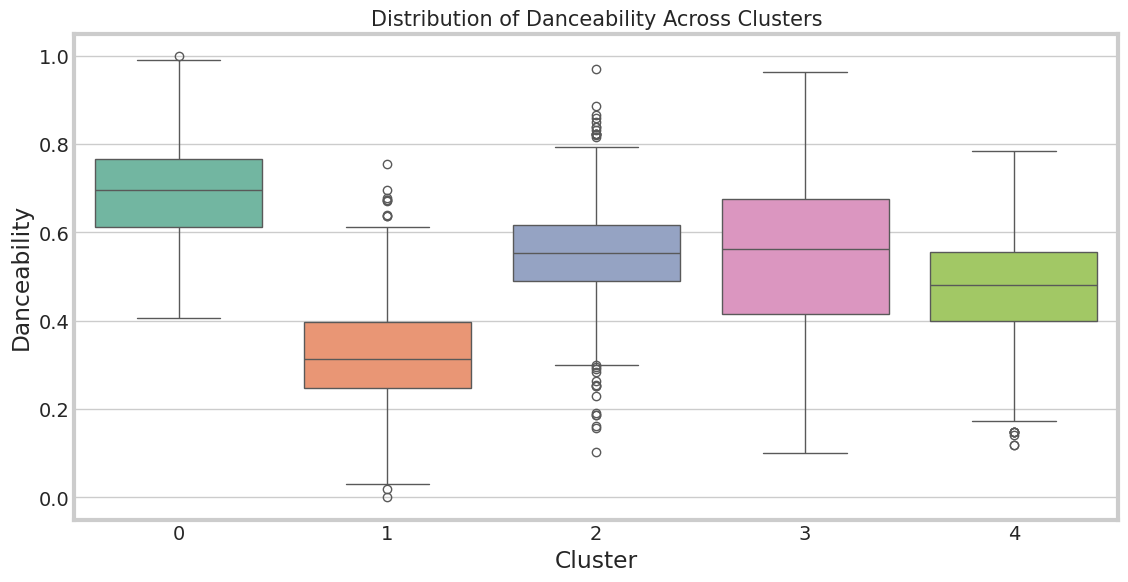

/tmp/ipython-input-3270647752.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


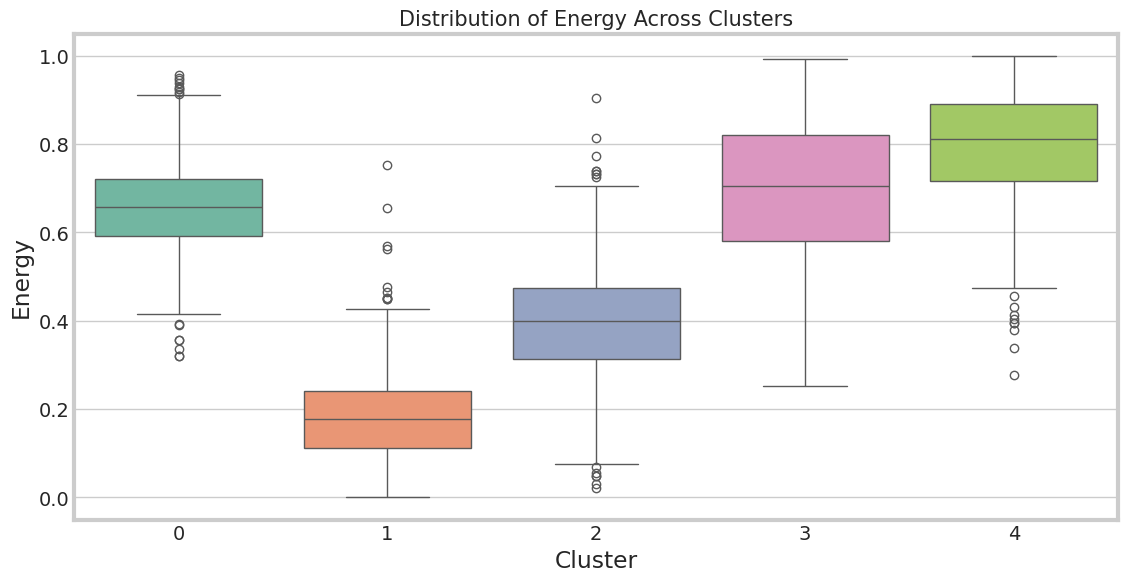

/tmp/ipython-input-3270647752.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


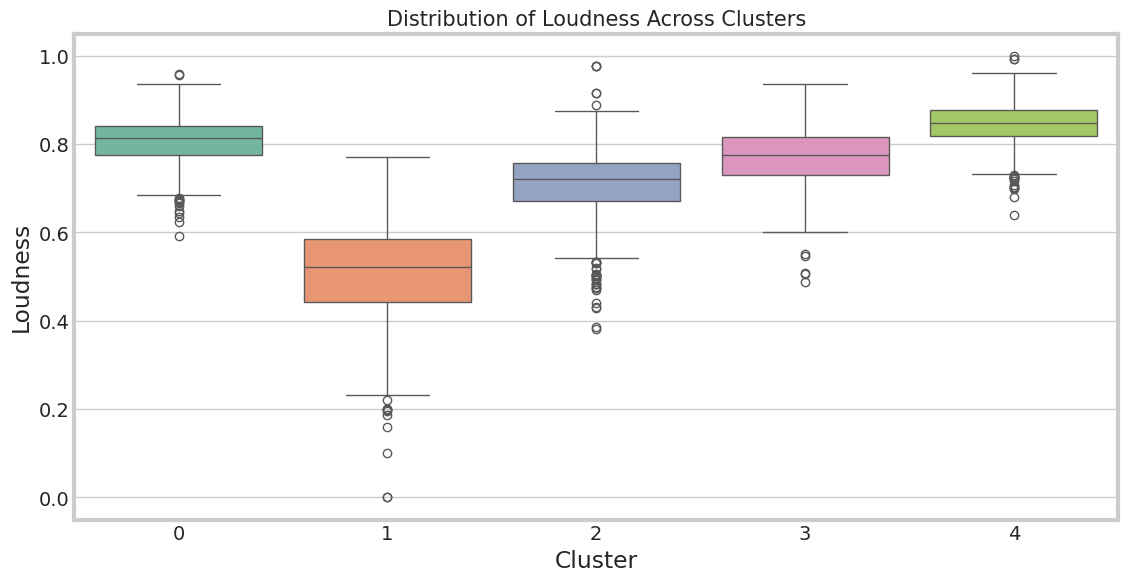

/tmp/ipython-input-3270647752.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


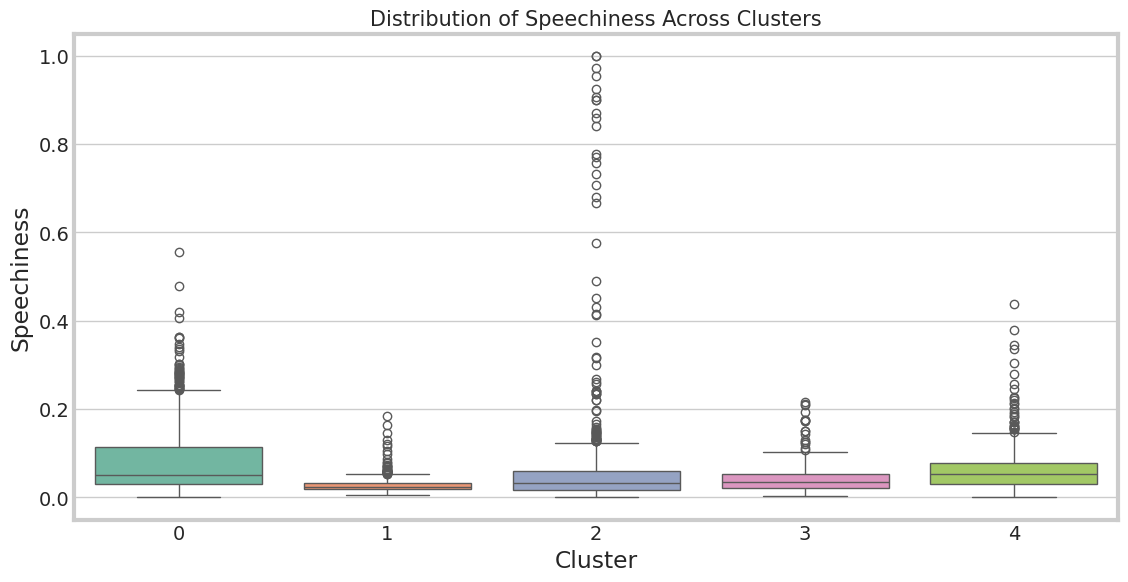

/tmp/ipython-input-3270647752.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


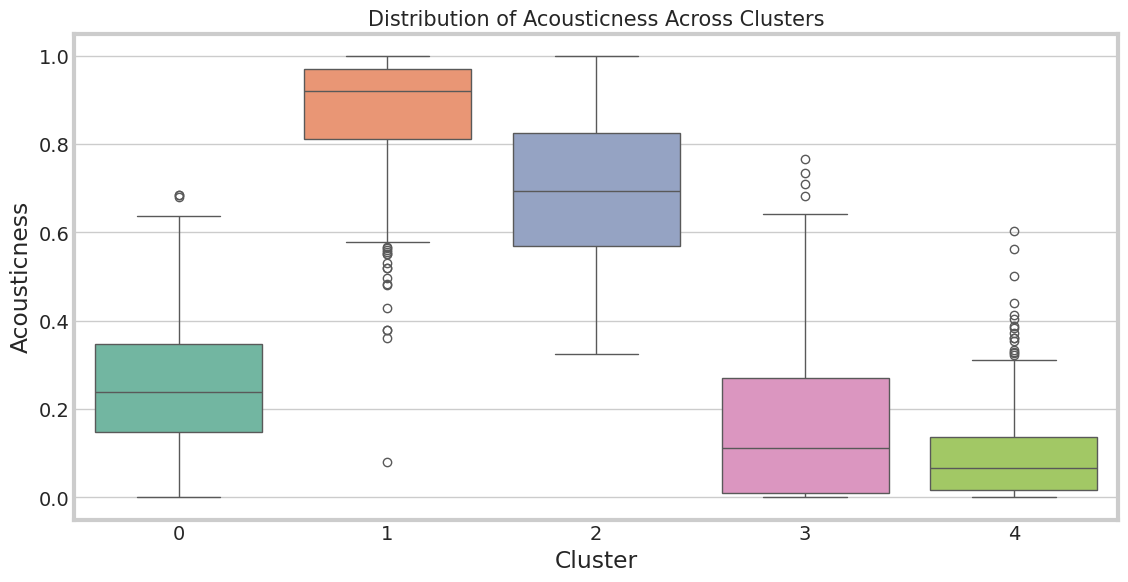

/tmp/ipython-input-3270647752.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


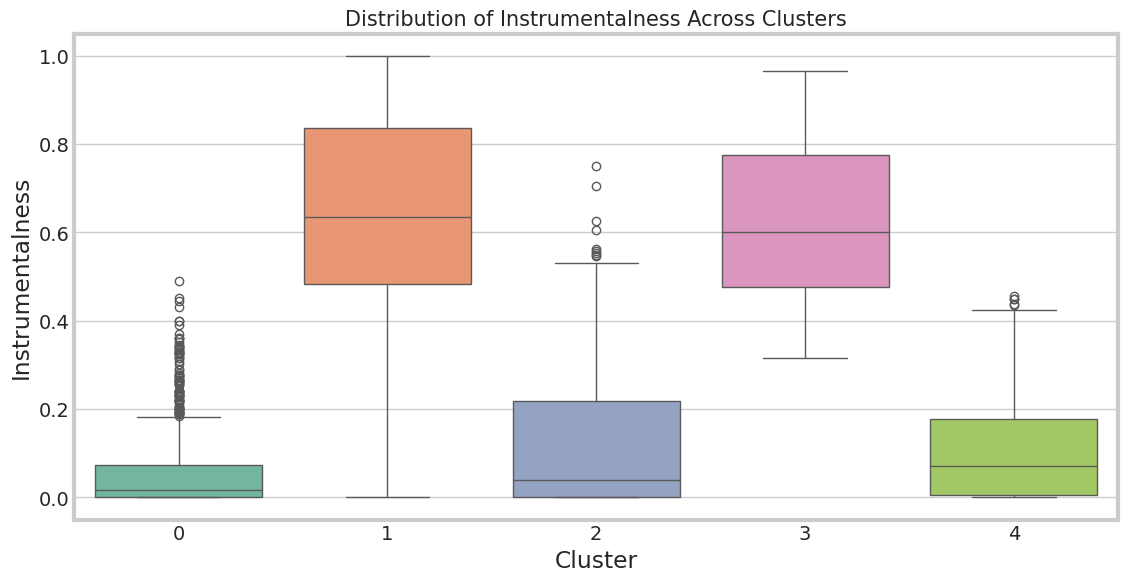

/tmp/ipython-input-3270647752.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


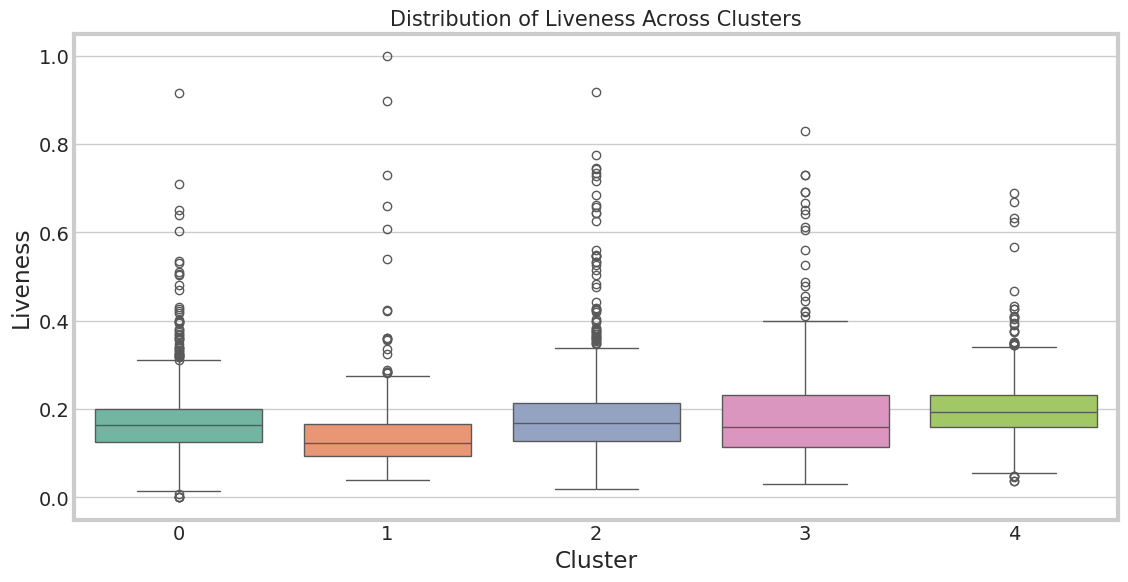

/tmp/ipython-input-3270647752.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


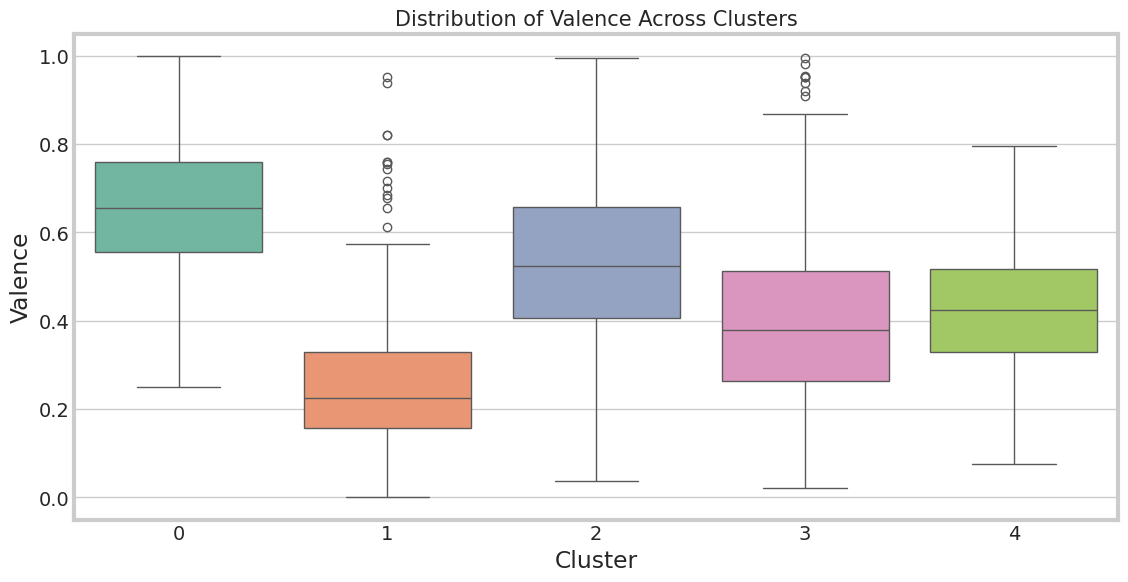

/tmp/ipython-input-3270647752.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


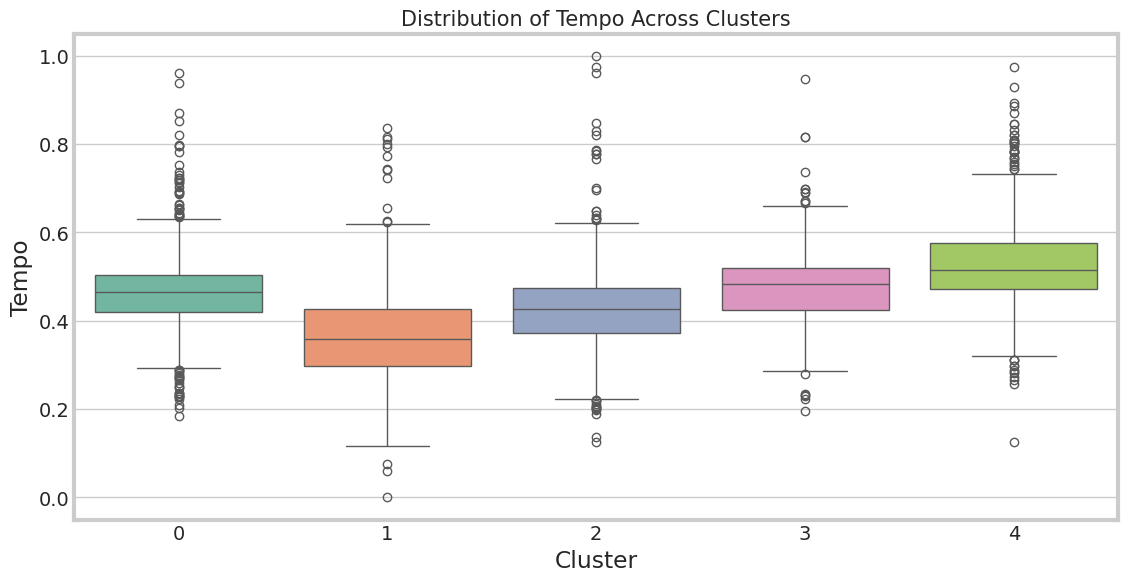

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# List of musical features used in clustering
features = [
    'danceability', 'energy', 'loudness', 'speechiness',
    'acousticness', 'instrumentalness', 'liveness',
    'valence', 'tempo'
]

# Create a boxplot for each feature
for feature in features:
    plt.figure(figsize=(12,6))

    sns.boxplot(
        x='cluster',
        y=feature,
        data=df,
        palette='Set2'
    )

    plt.title(f'Distribution of {feature.capitalize()} Across Clusters', fontsize=15)
    plt.xlabel('Cluster')
    plt.ylabel(feature.capitalize())
    plt.show()


1 Danceability Across Clusters

The boxplot shows clear differences in danceability between clusters.

Cluster 0 has the highest median danceability, indicating genres that are very suitable for dancing.

Cluster 1 has the lowest danceability values, suggesting calmer or more classical music styles.

Clusters 2 and 3 show moderate danceability, representing balanced genres.

Cluster 4 falls between moderate and high danceability.

Interpretation:
Danceability is a strong factor that separates clusters, helping distinguish dance-oriented genres from slower, less rhythmic ones.

2️ Energy Across Clusters

This plot highlights strong variation in energy levels:

Cluster 4 has the highest energy, indicating intense, powerful, and fast-paced music.

Cluster 3 also shows high energy but with more variation.

Cluster 1 has very low energy, representing calm and relaxed genres.

Cluster 0 shows moderately high energy.

Cluster 2 represents medium-energy music.

Interpretation:
Energy is one of the most influential features in clustering, clearly separating calm acoustic music from high-energy genres.

3️ Loudness Across Clusters

The loudness distribution closely follows the energy pattern:

Clusters 4 and 3 are the loudest, which is expected for energetic and amplified music.

Cluster 0 also shows high loudness but slightly lower than clusters 3 and 4.

Cluster 1 is the quietest cluster.

Cluster 2 lies in the middle.

Interpretation:
Loudness strongly correlates with energy and reinforces the distinction between soft acoustic genres and loud, high-energy genres.

4️ Speechiness Across Clusters

Speechiness values are generally low across all clusters, but differences still exist:

Cluster 2 has the highest spread and outliers, indicating genres with spoken words or rap-like elements.

Clusters 0, 3, and 4 have low to moderate speechiness.

Cluster 1 has the lowest speechiness.

Interpretation:
Speechiness helps identify clusters that include spoken vocals or rap-influenced genres, even though it is not the main clustering driver.

5️ Acousticness Across Clusters

This feature shows very strong separation:

Cluster 1 has extremely high acousticness, clearly representing acoustic, classical, or unplugged music.

Cluster 2 also has relatively high acousticness but less extreme.

Clusters 3 and 4 have very low acousticness.

Cluster 0 shows moderate acousticness.

Interpretation:
Acousticness is a key feature that clearly separates soft, acoustic genres from electronic and highly produced music.

6️ Instrumentalness Across Clusters

The instrumentalness plot shows strong contrast:

Cluster 1 and Cluster 3 have the highest instrumentalness values, indicating instrumental or classical genres.

Cluster 0 has very low instrumentalness, meaning vocals dominate.

Cluster 2 has mostly low values with some variation.

Cluster 4 is mostly low to moderate.

Interpretation:
Instrumentalness helps distinguish instrumental-focused genres from vocal-heavy music.

7️ Liveness Across Clusters

Liveness shows less variation compared to other features:

All clusters have similar median values.

Cluster 4 shows slightly higher liveness.

Some clusters contain outliers indicating live recordings.

Interpretation:
Liveness is not a strong clustering factor but provides minor differentiation related to live performance characteristics.

8️ Valence Across Clusters

Valence (musical positivity) differs clearly:

Cluster 0 has the highest valence, indicating happier and more positive music.

Cluster 1 has the lowest valence, representing sad or calm music.

Clusters 2 and 4 show moderate valence.

Cluster 3 leans toward lower-to-medium positivity.

Interpretation:
Valence helps separate emotionally positive music from darker or more serious genres.

9️ Tempo Across Clusters

Tempo differences are visible:

Cluster 4 has the fastest tempo on average.

Cluster 3 also shows relatively high tempo.

Cluster 1 has the slowest tempo.

Clusters 0 and 2 lie in the middle.

Interpretation:
Tempo supports the distinction between slow, relaxed genres and fast, energetic ones.

In [22]:
# Display 5 random genres from each cluster
from sklearn.metrics import silhouette_score

# Calculate the Silhouette Score
sil_score = silhouette_score(X, labels)

print("Silhouette Score:", sil_score)


Silhouette Score: 0.24255572874683537


The Silhouette Score is used to evaluate how well the clustering performed. It measures how similar each genre is to its own cluster compared to other clusters. The score ranges from −1 to +1, where higher values indicate better cluster separation.

The obtained Silhouette Score of 0.24 indicates a moderate clustering quality. This means that most genres are closer to their assigned cluster than to other clusters, but some overlap between clusters still exists. This result is expected for music data, as many genres share similar audio characteristics and do not form completely separate groups.

Final Recommendation:
Based on the Silhouette Score and the Elbow Method, using 5 clusters provides a reasonable balance between grouping similar genres and keeping the model simple. The clustering results are acceptable and meaningful for exploring similarities between music genres.

In [23]:
# Map numeric clusters to descriptive names
cluster_names = {
    0: 'High Energy',
    1: 'Danceable Hits',
    2: 'Acoustic/Soft',
    3: 'Instrumental Focus',
    4: 'Mixed Energy'
}

df['cluster_name'] = df['cluster'].map(cluster_names)


In [24]:
#Genre Recommendation Function

def genre_recommender(genre_input, df=df):

    # Check if the genre exists
    if genre_input not in df['genres'].values:
        return "Genre not found in dataset."

    # Find the cluster of the input genre
    cluster = df[df['genres'] == genre_input]['cluster'].iloc[0]

    # Get other genres from the same cluster
    similar_genres = df[df['cluster'] == cluster]['genres'].unique()

    # Remove the input genre itself
    similar_genres = [g for g in similar_genres if g != genre_input]

    # Return up to 5 similar genres
    return similar_genres[:5]



This function uses the clustering results to recommend similar music genres. When a genre is given as input, the function first checks if it exists in the dataset. It then finds the cluster that the genre belongs to and returns other genres from the same cluster. Since genres in the same cluster share similar musical features, the recommended genres are expected to sound similar. This demonstrates a practical use of the K-Means clustering model for genre recommendation.

the bonus one

In [25]:
genre_recommender('jazz')


['a cappella', 'accordion', 'acoustic blues', 'acoustic pop', 'acoustic rock']

When the genre “jazz” is given as input, the function returns a list of other genres from the same cluster. These genres share similar musical characteristics with jazz based on the audio features used in clustering. This result shows that the clustering model can successfully identify related genres and provide reasonable genre recommendations, demonstrating a practical application of K-Means clustering.